# HuBERT Audio Classifier: Plant_Sounds vs Normal vs Noise

โน้ตบุ๊กนี้สอนขั้นตอนการเทรนโมเดล **HuBERT** เพื่อจำแนกเสียง 3 คลาส:
- `Plant_Sounds`
- `Normal`
- `Noise`

แต่ละคลาสคือ 1 โฟลเดอร์ (ชื่อไฟล์ข้างในแต่ละโฟลเดอร์ไม่จำเป็นต้องเหมือนกัน เพราะเราใช้ "โฟลเดอร์" เป็นตัวกำหนด label ไม่ได้ดูจากชื่อไฟล์)

ไฟล์เสียงที่ใช้: `.wav`, ความยาว ~10 วินาที, 16kHz

ขั้นตอนทั้งหมด:
1. ติดตั้งไลบรารี
2. โหลด path และ label ของไฟล์เสียง
3. โชว์ waveform ตัวอย่างก่อนเทรน
4. เตรียม Dataset / DataLoader ด้วย HuBERT Feature Extractor
5. โหลดโมเดล HuBERT สำหรับ Sequence Classification (3 คลาส)
6. เทรนโมเดล
7. ประเมินผล (accuracy, confusion matrix, ROC/AUC แบบ One-vs-Rest)
8. บันทึกโมเดลเป็นไฟล์ `.pt`
9. สร้าง Gradio UI สำหรับอัพโหลดไฟล์เสียงมาวิเคราะห์ พร้อมโชว์ spectrogram


In [ ]:
# ติดตั้งไลบรารีที่จำเป็น
!pip install -q transformers torchaudio torch librosa matplotlib pandas scikit-learn gradio soundfile


In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from transformers import HubertForSequenceClassification, Wav2Vec2FeatureExtractor
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- Diagnostic: เช็คว่า PyTorch เห็น GPU จริงไหม (ปัญหาที่พบบ่อยที่สุดคือลง torch แบบ CPU-only มาโดยไม่รู้ตัว) ----
print("CUDA available:", torch.cuda.is_available())
print("Torch version:", torch.__version__)
print("Torch built with CUDA version:", torch.version.cuda)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("WARNING: ไม่พบ GPU! ถ้ามี GPU อยู่จริง (เช่น RTX 4050) แปลว่า PyTorch ที่ลงไว้เป็นเวอร์ชัน CPU-only")
    print("   ให้ลง PyTorch แบบ CUDA ใหม่ เช่น:")
    print("   pip uninstall torch torchvision torchaudio -y")
    print("   pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121")


Using device: cuda
CUDA available: True
Torch version: 2.7.0+cu126
Torch built with CUDA version: 12.6
GPU name: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
# ==== ตั้งค่า path หลัก แก้ตรงนี้ให้ตรงกับเครื่องของคุณ ====
# โครงสร้างที่คาดหวัง:
# ROOT_DIR/
#   Plant_Sounds/*.wav
#   Normal/*.wav
#   Noise/*.wav
#
# หมายเหตุ: ชื่อไฟล์ .wav ข้างในแต่ละโฟลเดอร์ไม่ต้องเหมือนกัน (เช่น ตั้งชื่อไฟล์ตามวันเวลาที่บันทึก)
# เพราะโค้ดนี้ใช้ "ชื่อโฟลเดอร์" เป็นตัวกำหนด label ไม่ได้อิงจากชื่อไฟล์เลย

ROOT_DIR = r"..."   # <-- แก้ path ตรงนี้ให้ชี้ไปยังโฟลเดอร์แม่ที่เก็บ 3 คลาส

CLASS_FOLDERS = {
    "Plant_Sounds": 0,
    "Normal": 1,
    "Noise": 2,
}

LABEL2NAME = {v: k for k, v in CLASS_FOLDERS.items()}
SAMPLE_RATE = 16000   # HuBERT ต้องการ sample rate 16kHz
MAX_DURATION = 1.0   # ความยาวไฟล์เสียงที่ใช้ (วินาที) -> ไฟล์ที่มีจะถูกตัด/pad ให้เท่ากับค่านี้เสมอ

print("Classes (name -> label id):", CLASS_FOLDERS)
print("Label id -> Name:", LABEL2NAME)


Classes (name -> label id): {'Plant_Sounds': 0, 'Normal': 1, 'Noise': 2}
Label id -> Name: {0: 'Plant_Sounds', 1: 'Normal', 2: 'Noise'}


In [42]:
# สแกนหาไฟล์ .wav ในแต่ละโฟลเดอร์คลาส แล้วสร้าง DataFrame เก็บ path + label
MAX_FILES_PER_CLASS = 250  # จำกัดจำนวนไฟล์ต่อคลาส เพื่อให้ balance กันและเทรนเร็วขึ้น

records = []
for folder_name, label in CLASS_FOLDERS.items():
    folder_path = os.path.join(ROOT_DIR, folder_name)
    wav_files = sorted(glob.glob(os.path.join(folder_path, "*.wav")))
    total_found = len(wav_files)

    # สุ่มเลือกมาไม่เกิน MAX_FILES_PER_CLASS ไฟล์ต่อคลาส (ถ้ามีมากกว่านั้น)
    if total_found > MAX_FILES_PER_CLASS:
        rng = random.Random(SEED)
        wav_files = rng.sample(wav_files, MAX_FILES_PER_CLASS)

    print(f"{folder_name}: พบ {total_found} ไฟล์ -> ใช้ {len(wav_files)} ไฟล์  (path: {folder_path})")
    for fp in wav_files:
        records.append({"filepath": fp, "label": label, "class_name": folder_name})

df = pd.DataFrame(records)
print("\nจำนวนไฟล์ทั้งหมดที่ใช้:", len(df))
df.head(10)


Plant_Sounds: พบ 304 ไฟล์ -> ใช้ 250 ไฟล์  (path: D:\file-law-5Group\new-make-group\HuBERT-Train\Plant_Sounds)
Normal: พบ 625 ไฟล์ -> ใช้ 250 ไฟล์  (path: D:\file-law-5Group\new-make-group\HuBERT-Train\Normal)
Noise: พบ 323 ไฟล์ -> ใช้ 250 ไฟล์  (path: D:\file-law-5Group\new-make-group\HuBERT-Train\Noise)

จำนวนไฟล์ทั้งหมดที่ใช้: 750


,filepath,label,class_name
0,D:\file-law-5Group\new-make-group\HuBERT-Train...,0,Plant_Sounds
1,D:\file-law-5Group\new-make-group\HuBERT-Train...,0,Plant_Sounds
2,D:\file-law-5Group\new-make-group\HuBERT-Train...,0,Plant_Sounds
3,D:\file-law-5Group\new-make-group\HuBERT-Train...,0,Plant_Sounds
4,D:\file-law-5Group\new-make-group\HuBERT-Train...,0,Plant_Sounds
5,D:\file-law-5Group\new-make-group\HuBERT-Train...,0,Plant_Sounds
6,D:\file-law-5Group\new-make-group\HuBERT-Train...,0,Plant_Sounds
7,D:\file-law-5Group\new-make-group\HuBERT-Train...,0,Plant_Sounds
8,D:\file-law-5Group\new-make-group\HuBERT-Train...,0,Plant_Sounds
9,D:\file-law-5Group\new-make-group\HuBERT-Train...,0,Plant_Sounds


class_name
Plant_Sounds    250
Normal          250
Noise           250
Name: count, dtype: int64


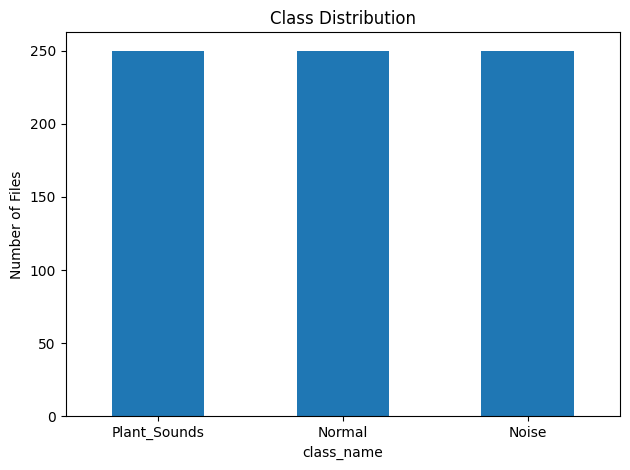

In [44]:
# โชว์จำนวนไฟล์ต่อคลาส
print(df["class_name"].value_counts())

df["class_name"].value_counts().plot(kind="bar", title="Class Distribution")
plt.xticks(rotation=0)
plt.ylabel("Number of Files")
plt.tight_layout()
plt.show()


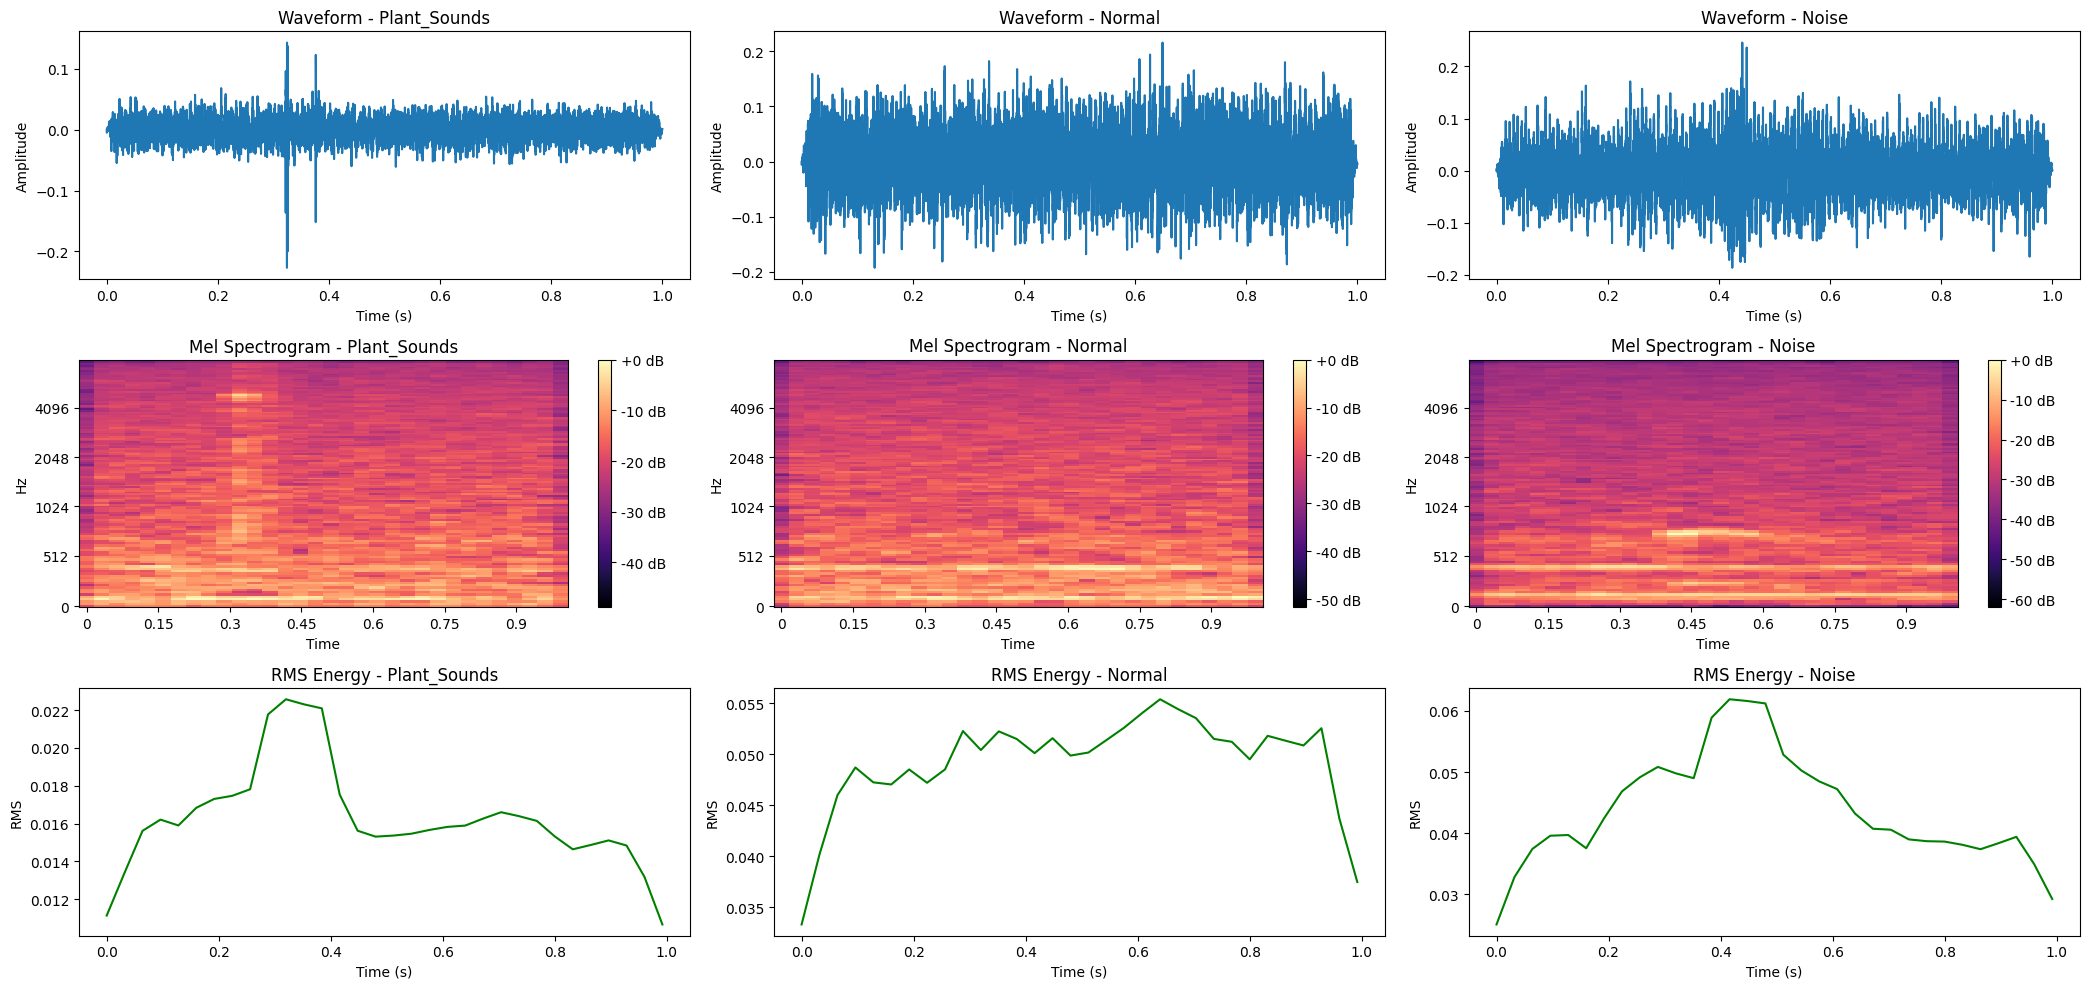

In [ ]:
# โชว์ waveform + spectrogram + RMS energy ของทุกคลาส "เทียบกันในรูปเดียว" เพื่อดูความแตกต่างชัด ๆ

class_names = list(CLASS_FOLDERS.keys())
fig, axes = plt.subplots(3, len(class_names), figsize=(7 * len(class_names), 10))

for col, folder_name in enumerate(class_names):
    subset = df[df["class_name"] == folder_name]
    if len(subset) == 0:
        print(f"ไม่พบไฟล์ในคลาส {folder_name}")
        continue

    sample_row = subset.sample(1, random_state=SEED).iloc[0]
    filepath = sample_row["filepath"]

    waveform, sr = torchaudio.load(filepath)
    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
        sr = SAMPLE_RATE
    waveform = waveform.mean(dim=0)  # รวมเป็น mono
    wav_np = waveform.numpy()

    # ---- แถวที่ 1: Waveform ----
    axes[0, col].plot(np.linspace(0, len(wav_np) / sr, len(wav_np)), wav_np)
    axes[0, col].set_title(f"Waveform - {folder_name}")
    axes[0, col].set_xlabel("Time (s)")
    axes[0, col].set_ylabel("Amplitude")

    # ---- แถวที่ 2: Mel Spectrogram ----
    S = librosa.feature.melspectrogram(y=wav_np, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1, col])
    axes[1, col].set_title(f"Mel Spectrogram - {folder_name}")
    fig.colorbar(img, ax=axes[1, col], format="%+2.0f dB")

    # ---- แถวที่ 3: RMS Energy ----
    rms = librosa.feature.rms(y=wav_np)[0]
    rms_times = librosa.frames_to_time(np.arange(len(rms)), sr=sr)
    axes[2, col].plot(rms_times, rms, color="green")
    axes[2, col].set_title(f"RMS Energy - {folder_name}")
    axes[2, col].set_xlabel("Time (s)")
    axes[2, col].set_ylabel("RMS")

plt.tight_layout()
plt.show()


In [ ]:
# แบ่งข้อมูลเป็น Train / Validation / Test แบบ stratified ตาม label
# Train 70% -> ใช้เทรนโมเดล
# Validation 15% -> ใช้เลือก checkpoint ที่ดีที่สุด (early stopping) ระหว่างเทรน
# Test 15% -> เก็บไว้เทส "หลังเทรนเสร็จ" เท่านั้น ไม่เคยถูกใช้ตัดสินใจอะไรระหว่างเทรนเลย (holdout จริง ๆ)

train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df), "  Val:", len(val_df), "  Test:", len(test_df))
print("\nTrain distribution:\n", train_df["class_name"].value_counts())
print("\nVal distribution:\n", val_df["class_name"].value_counts())
print("\nTest distribution:\n", test_df["class_name"].value_counts())


Train: 525   Val: 112   Test: 113

Train distribution:
 class_name
Plant_Sounds    175
Normal          175
Noise           175
Name: count, dtype: int64

Val distribution:
 class_name
Plant_Sounds    38
Normal          37
Noise           37
Name: count, dtype: int64

Test distribution:
 class_name
Noise           38
Normal          38
Plant_Sounds    37
Name: count, dtype: int64


In [ ]:
# โหลด HuBERT Feature Extractor 
MODEL_NAME = "facebook/hubert-base-ls960"

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)
feature_extractor


Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0,
  "return_attention_mask": false,
  "sampling_rate": 16000
}

### (Optional) EDA: วิเคราะห์ HuBERT Embedding ด้วย PCA + K-means

ก่อนเทรน classifier ลองดึง embedding จาก HuBERT แบบ base (ยังไม่ fine-tune) มาลดมิติด้วย PCA
แล้วลอง K-means clustering ดูว่าเสียงแต่ละคลาสแยกกันชัดเจนแค่ไหนในปริภูมิ embedding
ถ้าแยกชัดตั้งแต่ยังไม่เทรน แปลว่า HuBERT feature มีข้อมูลพอให้ classifier เรียนรู้ได้ง่าย


In [8]:
from transformers import HubertModel
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# โหลด HuBERT แบบ base (ไม่มี classification head) มาใช้ดึง embedding อย่างเดียว
embedding_model = HubertModel.from_pretrained(MODEL_NAME)
embedding_model.to(device)
embedding_model.eval()

def extract_embedding(filepath):
    waveform, sr = torchaudio.load(filepath)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
    wav_np = waveform.squeeze(0).numpy()

    inputs = feature_extractor(wav_np, sampling_rate=SAMPLE_RATE, return_tensors="pt")
    input_values = inputs["input_values"].to(device)

    with torch.no_grad():
        outputs = embedding_model(input_values=input_values)
        hidden_states = outputs.last_hidden_state  # [1, T, H]
        embedding = hidden_states.mean(dim=1).squeeze(0)  # mean pooling ตามแกนเวลา

    return embedding.cpu().numpy()

embeddings = []
labels_list = []

for _, row in df.iterrows():
    emb = extract_embedding(row["filepath"])
    embeddings.append(emb)
    labels_list.append(row["label"])

embeddings = np.array(embeddings)
labels_arr = np.array(labels_list)

print("Embedding shape:", embeddings.shape)


Embedding shape: (750, 768)


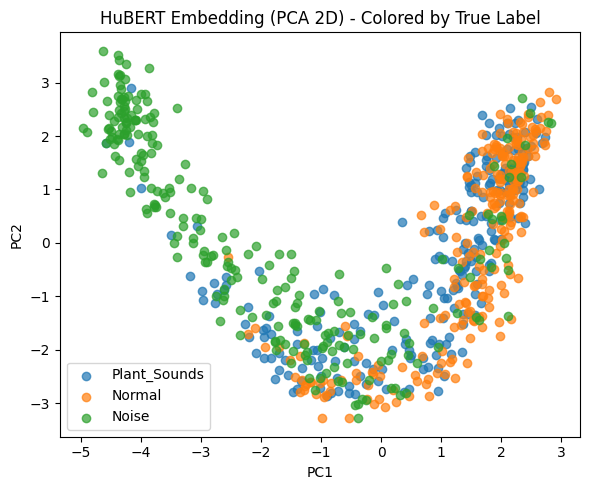

In [9]:
# ลดมิติ embedding เหลือ 2 มิติด้วย PCA แล้วโชว์ตาม label จริง
pca = PCA(n_components=2, random_state=SEED)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(6, 5))
for label, name in LABEL2NAME.items():
    mask = labels_arr == label
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], label=name, alpha=0.7)
plt.title("HuBERT Embedding (PCA 2D) - Colored by True Label")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()


Adjusted Rand Index (K-means vs Label จริง): 0.1820
(ยิ่งใกล้ 1 แปลว่า K-means จัดกลุ่มได้ตรงกับ label จริงมาก, ใกล้ 0 แปลว่าแยกไม่ค่อยออก)


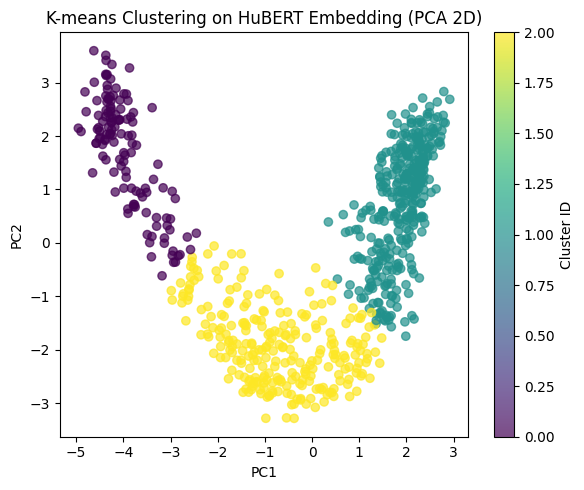

In [10]:
# ลอง K-means clustering บน embedding แล้วเทียบกับ label จริง
kmeans = KMeans(n_clusters=len(CLASS_FOLDERS), random_state=SEED, n_init=10)
cluster_ids = kmeans.fit_predict(embeddings)

ari = adjusted_rand_score(labels_arr, cluster_ids)
print(f"Adjusted Rand Index (K-means vs Label จริง): {ari:.4f}")
print("(ยิ่งใกล้ 1 แปลว่า K-means จัดกลุ่มได้ตรงกับ label จริงมาก, ใกล้ 0 แปลว่าแยกไม่ค่อยออก)")

plt.figure(figsize=(6, 5))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_ids, cmap="viridis", alpha=0.7)
plt.title("K-means Clustering on HuBERT Embedding (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()
plt.show()


In [11]:
class HubertAudioDataset(Dataset):
    """Dataset สำหรับโหลดไฟล์ wav -> waveform -> HuBERT feature extractor"""

    def __init__(self, dataframe, feature_extractor, sample_rate=16000, max_duration=1.0, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.fe = feature_extractor
        self.sr = sample_rate
        self.max_len = int(sample_rate * max_duration)
        self.augment = augment  # เปิดเฉพาะตอนเทรน เพื่อลด overfitting

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform, sr = torchaudio.load(row["filepath"])

        # รวมเป็น mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # resample ถ้า sample rate ไม่ตรง 16kHz
        if sr != self.sr:
            waveform = torchaudio.functional.resample(waveform, sr, self.sr)

        waveform = waveform.squeeze(0).numpy()

        # ตัด/pad ให้ความยาวเท่ากันทุกไฟล์ (ตามค่า max_duration ที่ตั้งไว้)
        if len(waveform) > self.max_len:
            waveform = waveform[: self.max_len]
        else:
            pad = self.max_len - len(waveform)
            waveform = np.pad(waveform, (0, pad))

        # ---- Data Augmentation (เฉพาะตอนเทรน) เพื่อลด overfitting ----
        if self.augment:
            # 1) เติม Gaussian noise เบา ๆ แบบสุ่ม (โอกาส 50%)
            if random.random() < 0.5:
                noise_level = np.random.uniform(0.001, 0.01)
                waveform = waveform + (np.random.randn(len(waveform)).astype(np.float32) * noise_level)

            # 2) สุ่ม time-shift เลื่อนคลื่นเสียงไปมา แบบสัดส่วนของความยาวคลิป (±5% ของ max_len) (โอกาส 50%)
            #    ใช้ max_len แทนค่าคงที่ 0.1 วินาที เพราะคลิปสั้น (1 วิ) ถ้า shift คงที่จะกลายเป็นสัดส่วนที่แรงเกินไป
            if random.random() < 0.5:
                shift_range = max(1, int(0.05 * self.max_len))
                shift = np.random.randint(-shift_range, shift_range + 1)
                waveform = np.roll(waveform, shift)

        inputs = self.fe(waveform, sampling_rate=self.sr, return_tensors="pt")
        input_values = inputs["input_values"].squeeze(0)

        return input_values, row["label"]


In [12]:
def collate_fn(batch):
    input_values, labels = zip(*batch)
    input_values = torch.stack(input_values)
    labels = torch.tensor(labels, dtype=torch.long)
    return input_values, labels

BATCH_SIZE = 8  # เพิ่มจาก 4 -> 8 เพื่อให้แต่ละ epoch ใช้ step น้อยลง (เทรนเร็วขึ้น)
NUM_WORKERS = 0  # บน Windows/Jupyter ตั้งเป็น 0 เพื่อกัน DataLoader worker พัง (multiprocessing มีปัญหาบน Windows)

# augment=True เฉพาะ train_dataset เท่านั้น val/test ต้องคงข้อมูลจริงไว้ ไม่ augment
train_dataset = HubertAudioDataset(train_df, feature_extractor, SAMPLE_RATE, max_duration=MAX_DURATION, augment=True)
val_dataset = HubertAudioDataset(val_df, feature_extractor, SAMPLE_RATE, max_duration=MAX_DURATION, augment=False)
test_dataset = HubertAudioDataset(test_df, feature_extractor, SAMPLE_RATE, max_duration=MAX_DURATION, augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)

# ทดสอบดึงมา 1 batch เพื่อเช็ค shape
sample_x, sample_y = next(iter(train_loader))
print("Input shape:", sample_x.shape)
print("Labels:", sample_y)


Input shape: torch.Size([8, 16000])
Labels: tensor([1, 0, 2, 0, 1, 2, 0, 1])


In [13]:
# โหลดโมเดล HuBERT พร้อม classification head ตามจำนวนคลาสใน CLASS_FOLDERS
NUM_LABELS = len(CLASS_FOLDERS)

model = HubertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    label2id=CLASS_FOLDERS,
    id2label=LABEL2NAME,
)
model.to(device)

print(f"จำนวนคลาส: {NUM_LABELS} -> {list(CLASS_FOLDERS.keys())}")
print(f"จำนวน parameters ทั้งหมด: {sum(p.numel() for p in model.parameters()):,}")


Some weights of HubertForSequenceClassification were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


จำนวนคลาส: 3 -> ['Plant_Sounds', 'Normal', 'Noise']
จำนวน parameters ทั้งหมด: 94,569,347


In [14]:
# freeze ส่วน feature encoder (CNN layer) เพื่อเทรนเร็วขึ้นและลด overfit บนข้อมูลจำนวนน้อย
model.freeze_feature_encoder()

# ---- Freeze เฉพาะ transformer layers ล่างสุด 1 ใน 4 ----
# (ตอนนี้คลิปสั้นแค่ 1 วิ ทำให้แต่ละ step เบามาก จึงเปิดให้ fine-tune layer ได้มากขึ้นกว่าตอนคลิป 10 วิ
#  เพื่อให้โมเดลปรับตัวกับ context สั้น ๆ ได้ดีขึ้น โดยยังพอมี layer ล่างสุด freeze ไว้กัน overfit บ้าง)
transformer_layers = model.hubert.encoder.layers
NUM_LAYERS_TO_FREEZE = len(transformer_layers) // 4
for i, layer in enumerate(transformer_layers):
    if i < NUM_LAYERS_TO_FREEZE:
        for p in layer.parameters():
            p.requires_grad = False

print(f"Freeze {NUM_LAYERS_TO_FREEZE}/{len(transformer_layers)} transformer layers ล่างสุด (fine-tune เฉพาะ layer บนกับ head)")

# ⚠️ ใช้ learning rate แยกกันระหว่าง backbone กับ classifier head
# backbone (transformer ของ HuBERT) ถูก pretrain มาแล้ว -> ใช้ lr ต่ำ ๆ พอปรับละเอียด
# ส่วน projector/classifier เป็น layer ใหม่ที่สุ่มค่าเริ่มต้น -> ต้องใช้ lr สูงกว่ามาก ไม่งั้นจะขยับช้าจนดูเหมือนไม่เรียนรู้เลย (Acc ค้างที่ 0.50)
# .filter เอาเฉพาะ param ที่ requires_grad=True (ตัวที่ freeze ไปจะไม่ถูกส่งเข้า optimizer เลย ประหยัด memory/เวลา)
head_params = [p for n, p in model.named_parameters() if (n.startswith("classifier") or n.startswith("projector")) and p.requires_grad]
backbone_params = [p for n, p in model.named_parameters() if not (n.startswith("classifier") or n.startswith("projector")) and p.requires_grad]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 0.00001, "weight_decay": 0.01},
    {"params": head_params, "lr": 0.0003, "weight_decay": 0.01},
])

# ---- Class Weight: ให้ loss ถ่วงน้ำหนักตามความถี่ของแต่ละคลาสใน train set ----
# คลาสที่มีไฟล์น้อย (เช่น Plant_Sounds) จะได้ weight สูงกว่า คลาสที่มีไฟล์เยอะ (เช่น Normal)
# ป้องกันไม่ให้โมเดลเอนเอียงไปทายคลาสที่เจอบ่อยกว่าเพียงเพราะมันมีจำนวนมากกว่า
from sklearn.utils.class_weight import compute_class_weight

class_labels_sorted = sorted(CLASS_FOLDERS.values())
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(class_labels_sorted),
    y=train_df["label"].values,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("จำนวนไฟล์ต่อคลาสใน train set:")
print(train_df["class_name"].value_counts())
print("\nClass weight ที่คำนวณได้ (เรียงตาม label id 0,1,2,...):")
for lbl, w in zip(class_labels_sorted, class_weights):
    print(f"  {LABEL2NAME[lbl]} (label {lbl}): weight = {w:.4f}")

loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

EPOCHS = 40  # เพิ่มจาก 30 -> 40 เพราะคลิป 1 วิเทรนเร็วมาก เผื่อเวลาให้โมเดลเรียนรู้ได้ละเอียดขึ้น

from transformers import get_linear_schedule_with_warmup

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

# ---- Mixed Precision (AMP): เทรนเร็วขึ้นบน GPU โดยไม่ลดความแม่นยำมากนัก ----
from torch.cuda.amp import autocast, GradScaler

USE_AMP = torch.cuda.is_available()
scaler = GradScaler(enabled=USE_AMP)
print(f"ใช้ Mixed Precision (AMP): {USE_AMP}  (ถ้าไม่มี GPU จะเทรนแบบปกติ ไม่ error)")


Freeze 3/12 transformer layers ล่างสุด (fine-tune เฉพาะ layer บนกับ head)
จำนวนไฟล์ต่อคลาสใน train set:
class_name
Plant_Sounds    175
Normal          175
Noise           175
Name: count, dtype: int64

Class weight ที่คำนวณได้ (เรียงตาม label id 0,1,2,...):
  Plant_Sounds (label 0): weight = 1.0000
  Normal (label 1): weight = 1.0000
  Noise (label 2): weight = 1.0000
ใช้ Mixed Precision (AMP): True  (ถ้าไม่มี GPU จะเทรนแบบปกติ ไม่ error)


In [15]:
def train_one_epoch(model, loader, optimizer, loss_fn, device, scheduler=None, scaler=None):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    use_amp = scaler is not None and scaler.is_enabled()

    for input_values, labels in loader:
        input_values, labels = input_values.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(input_values=input_values)
                loss = loss_fn(outputs.logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(input_values=input_values)
            loss = loss_fn(outputs.logits, labels)
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item() * input_values.size(0)
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    use_amp = torch.cuda.is_available()
    with torch.no_grad():
        for input_values, labels in loader:
            input_values, labels = input_values.to(device), labels.to(device)
            with autocast(enabled=use_amp):
                outputs = model(input_values=input_values)
                loss = loss_fn(outputs.logits, labels)

            total_loss += loss.item() * input_values.size(0)
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_preds, all_labels


In [16]:
import copy

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# ---- Early Stopping setup: เก็บ checkpoint ที่ val_loss ต่ำที่สุด แทนการใช้ weight ของ epoch สุดท้าย ----
best_val_loss = float("inf")
best_state_dict = None
patience = 8  # เพิ่มจาก 6 -> 8 เผื่อพื้นที่ให้โมเดลเรียนต่อ เพราะคลิปสั้นเทรนเร็ว ไม่เสียเวลามาก
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, device, scheduler=scheduler, scaler=scaler)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, loss_fn, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"⏹ Early stopping ที่ epoch {epoch} (val_loss ไม่ดีขึ้นติดกัน {patience} epoch)")
            break

# โหลด weight ที่ val_loss ต่ำสุดกลับมาใช้ (กัน overfit จาก epoch ท้าย ๆ)
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"✅ โหลด checkpoint ที่ดีที่สุดกลับมาใช้ (Best Val Loss = {best_val_loss:.4f})")


Epoch 1/40 | Train Loss: 1.0972 Acc: 0.3371 | Val Loss: 1.0750 Acc: 0.4464
Epoch 2/40 | Train Loss: 1.0555 Acc: 0.4229 | Val Loss: 1.0102 Acc: 0.4375
Epoch 3/40 | Train Loss: 0.8820 Acc: 0.5543 | Val Loss: 0.8016 Acc: 0.5714
Epoch 4/40 | Train Loss: 0.8444 Acc: 0.5638 | Val Loss: 0.7640 Acc: 0.5714
Epoch 5/40 | Train Loss: 0.8412 Acc: 0.5600 | Val Loss: 0.6084 Acc: 0.7232
Epoch 6/40 | Train Loss: 0.6814 Acc: 0.6743 | Val Loss: 0.5577 Acc: 0.6964
Epoch 7/40 | Train Loss: 0.7362 Acc: 0.6019 | Val Loss: 0.5761 Acc: 0.6518
Epoch 8/40 | Train Loss: 0.7008 Acc: 0.6571 | Val Loss: 0.5899 Acc: 0.6429
Epoch 9/40 | Train Loss: 0.6455 Acc: 0.6743 | Val Loss: 0.5005 Acc: 0.8304
Epoch 10/40 | Train Loss: 0.6114 Acc: 0.6857 | Val Loss: 0.6748 Acc: 0.6607
Epoch 11/40 | Train Loss: 0.6299 Acc: 0.6914 | Val Loss: 0.5094 Acc: 0.7411
Epoch 12/40 | Train Loss: 0.5797 Acc: 0.7162 | Val Loss: 0.4544 Acc: 0.8661
Epoch 13/40 | Train Loss: 0.5647 Acc: 0.7505 | Val Loss: 0.4170 Acc: 0.8125
Epoch 14/40 | Train L

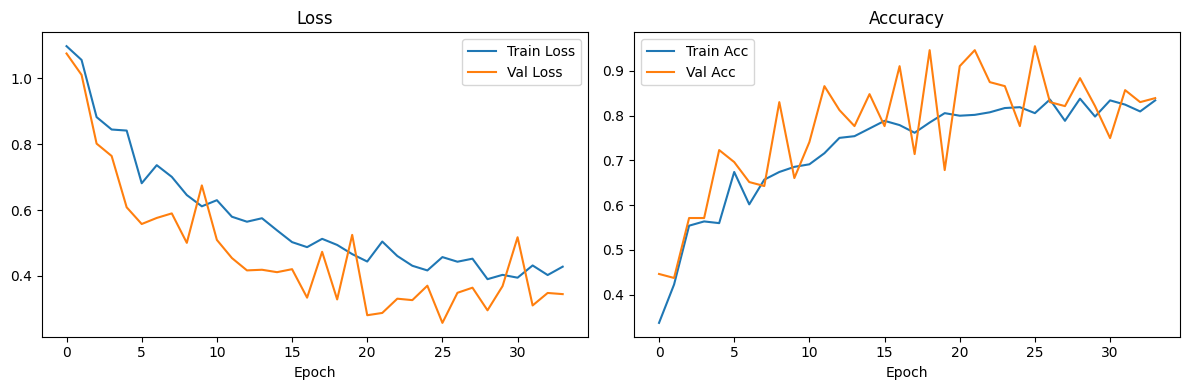

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


### กราฟ Training Curve อีกสไตล์หนึ่ง (log_history)

เซลถัดไปแปลงผลจาก `history` ให้อยู่ในรูป `log_history` (list ของ dict ต่อ epoch) แล้ว plot ในสไตล์จุด/เส้นตามตัวอย่าง


In [18]:
# แปลง history ให้อยู่ในรูป log_history (list ของ dict ต่อ epoch)
log_history = [
    {
        "epoch": i + 1,
        "train_loss": history["train_loss"][i],
        "train_acc": history["train_acc"][i],
        "val_loss": history["val_loss"][i],
        "val_acc": history["val_acc"][i],
    }
    for i in range(len(history["train_loss"]))
]

log_history


[{'epoch': 1,
  'train_loss': 1.0972284223919824,
  'train_acc': 0.33714285714285713,
  'val_loss': 1.0750296456473214,
  'val_acc': 0.44642857142857145},
 {'epoch': 2,
  'train_loss': 1.0554640992482502,
  'train_acc': 0.4228571428571429,
  'val_loss': 1.0101972307477678,
  'val_acc': 0.4375},
 {'epoch': 3,
  'train_loss': 0.8819973026003156,
  'train_acc': 0.5542857142857143,
  'val_loss': 0.8015523638044085,
  'val_acc': 0.5714285714285714},
 {'epoch': 4,
  'train_loss': 0.8443643333798363,
  'train_acc': 0.5638095238095238,
  'val_loss': 0.7640300478254046,
  'val_acc': 0.5714285714285714},
 {'epoch': 5,
  'train_loss': 0.8411833553087144,
  'train_acc': 0.56,
  'val_loss': 0.6083918980189732,
  'val_acc': 0.7232142857142857},
 {'epoch': 6,
  'train_loss': 0.6813613672483535,
  'train_acc': 0.6742857142857143,
  'val_loss': 0.5576659270695278,
  'val_acc': 0.6964285714285714},
 {'epoch': 7,
  'train_loss': 0.7361626724685941,
  'train_acc': 0.6019047619047619,
  'val_loss': 0.57608

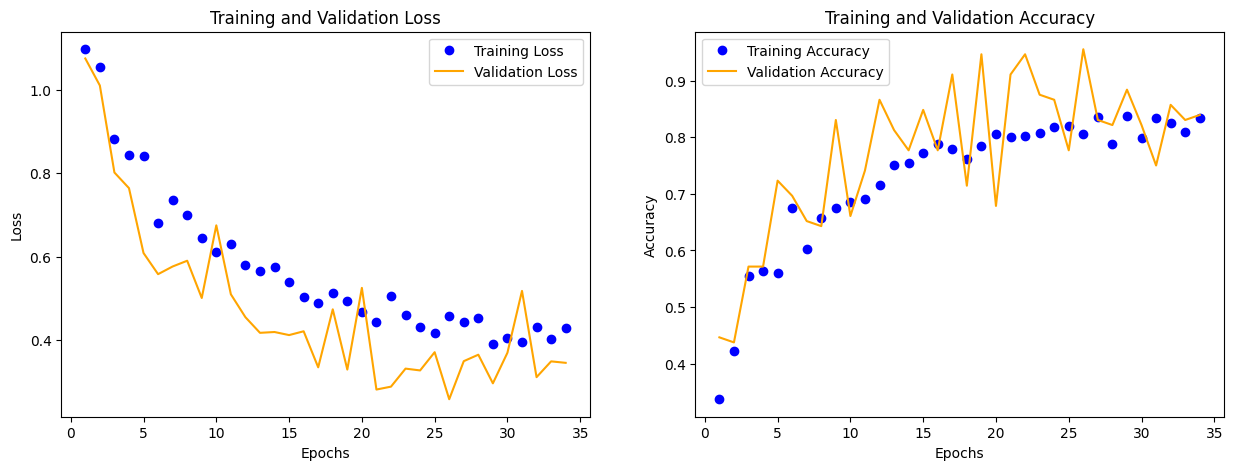

In [19]:
import matplotlib.pyplot as plt

# ดึงค่าจาก log_history
loss_values = [l['train_loss'] for l in log_history]
val_loss_values = [l['val_loss'] for l in log_history]
acc_values = [l['train_acc'] for l in log_history]
val_acc_values = [l['val_acc'] for l in log_history]
epochs = range(1, len(log_history) + 1)

# วาดกราฟ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# กราฟ Loss
ax1.plot(epochs, loss_values, 'bo', label='Training Loss')
ax1.plot(epochs, val_loss_values, 'orange', label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# กราฟ Accuracy
ax2.plot(epochs, acc_values, 'bo', label='Training Accuracy')
ax2.plot(epochs, val_acc_values, 'orange', label='Validation Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()


Test Accuracy: 0.9734513274336283

Classification Report:

              precision    recall  f1-score   support

Plant_Sounds       1.00      1.00      1.00        37
      Normal       0.93      1.00      0.96        38
       Noise       1.00      0.92      0.96        38

    accuracy                           0.97       113
   macro avg       0.98      0.97      0.97       113
weighted avg       0.98      0.97      0.97       113



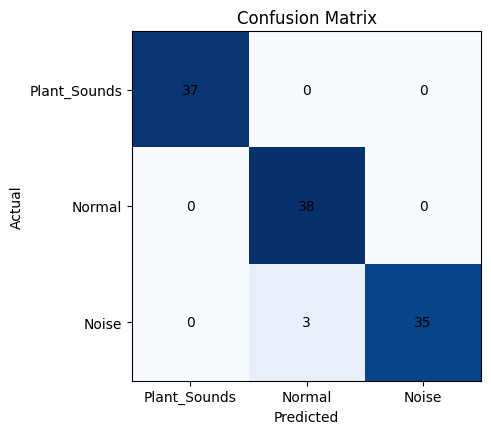

In [45]:
_, final_acc, final_preds, final_labels = evaluate(model, test_loader, loss_fn, device)
print("Test Accuracy:", final_acc)
print("\nClassification Report:\n")
print(classification_report(final_labels, final_preds, target_names=list(CLASS_FOLDERS.keys())))

n_classes = len(CLASS_FOLDERS)
cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(n_classes), list(CLASS_FOLDERS.keys()), rotation=0)
plt.yticks(range(n_classes), list(CLASS_FOLDERS.keys()))
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### ไฟล์ที่ทำนายผิด (Misclassified Samples)

ดึงเฉพาะไฟล์ใน validation set ที่โมเดลทายผิด มาโชว์ชื่อไฟล์ + label จริง/label ที่ทาย พร้อม waveform และ spectrogram
เพื่อช่วยวิเคราะห์ว่าโมเดลสับสนกับเสียงแบบไหน (มีประโยชน์มากตอนเขียนวิเคราะห์ผลในเล่มโปรเจค)


จำนวนไฟล์ที่ทายผิดทั้งหมด: 3 จาก 113 ไฟล์ใน test set

ไฟล์: 08-07_s1_291_noise_7.05s.wav
  Path: D:\file-law-5Group\new-make-group\HuBERT-Train\Noise\08-07_s1_291_noise_7.05s.wav
  True label: Noise  |  Predicted: Normal


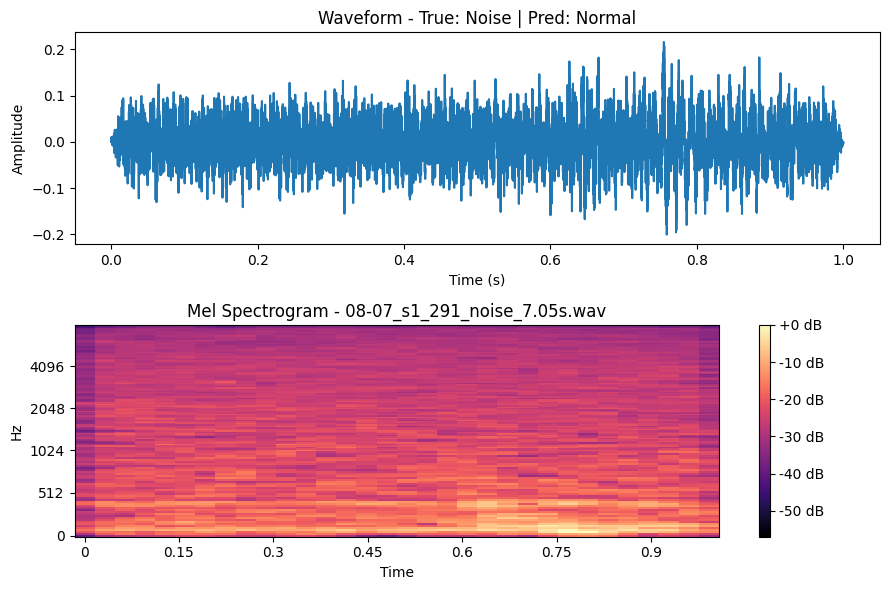


ไฟล์: 10-07_s2_203_noise_7.44s.wav
  Path: D:\file-law-5Group\new-make-group\HuBERT-Train\Noise\10-07_s2_203_noise_7.44s.wav
  True label: Noise  |  Predicted: Normal


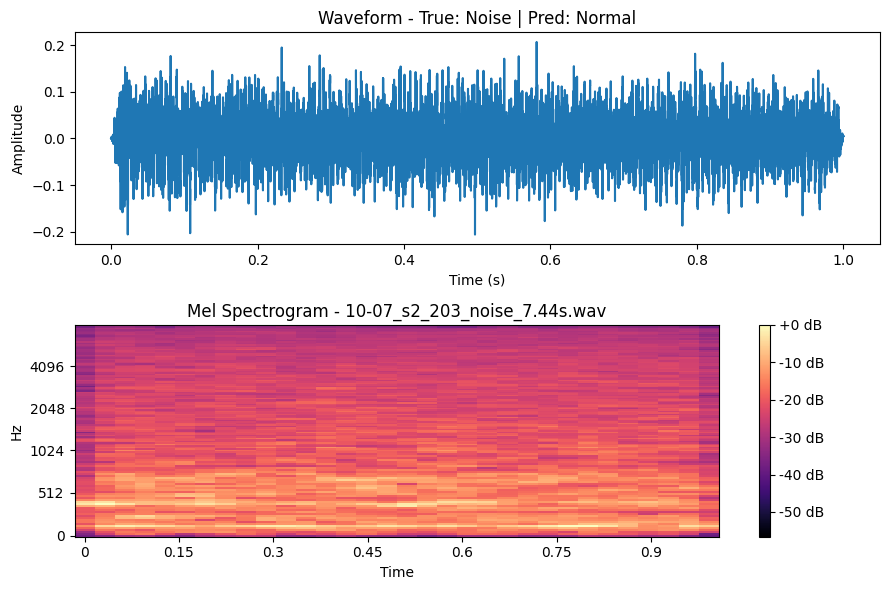


ไฟล์: 07-07_s2_223_noise_2.88s.wav
  Path: D:\file-law-5Group\new-make-group\HuBERT-Train\Noise\07-07_s2_223_noise_2.88s.wav
  True label: Noise  |  Predicted: Normal


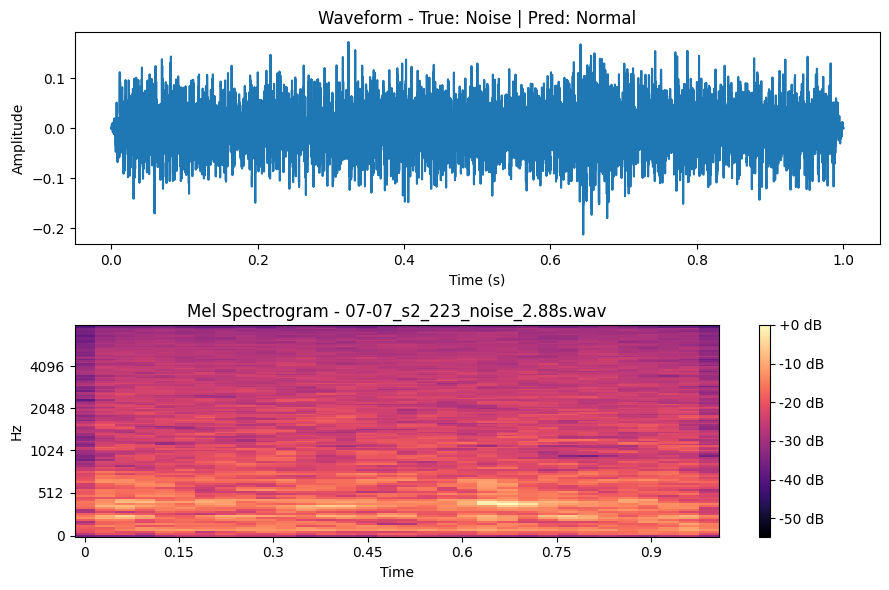

In [21]:
# หาไฟล์ที่โมเดลทายผิดใน test set (holdout ที่ไม่เคยใช้ตอนเทรน/เลือก checkpoint เลย) พร้อมโชว์ waveform + spectrogram
# หมายเหตุ: test_loader ตั้ง shuffle=False จึงอ้างอิงลำดับตรงกับ test_df ได้เลย

misclassified_idx = [i for i, (p, l) in enumerate(zip(final_preds, final_labels)) if p != l]
print(f"จำนวนไฟล์ที่ทายผิดทั้งหมด: {len(misclassified_idx)} จาก {len(final_labels)} ไฟล์ใน test set")

if len(misclassified_idx) == 0:
    print("ไม่มีไฟล์ที่ทายผิดเลยในชุด test นี้ 🎉")
else:
    for idx in misclassified_idx:
        row = test_df.iloc[idx]
        filepath = row["filepath"]
        true_label = LABEL2NAME[final_labels[idx]]
        pred_label = LABEL2NAME[final_preds[idx]]

        print(f"\nไฟล์: {os.path.basename(filepath)}")
        print(f"  Path: {filepath}")
        print(f"  True label: {true_label}  |  Predicted: {pred_label}")

        waveform, sr = torchaudio.load(filepath)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if sr != SAMPLE_RATE:
            waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
            sr = SAMPLE_RATE
        wav_np = waveform.squeeze(0).numpy()

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

        ax1.plot(np.linspace(0, len(wav_np) / sr, len(wav_np)), wav_np)
        ax1.set_title(f"Waveform - True: {true_label} | Pred: {pred_label}")
        ax1.set_xlabel("Time (s)")
        ax1.set_ylabel("Amplitude")

        S = librosa.feature.melspectrogram(y=wav_np, sr=sr, n_mels=128)
        S_db = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=ax2)
        ax2.set_title(f"Mel Spectrogram - {os.path.basename(filepath)}")
        fig.colorbar(img, ax=ax2, format="%+2.0f dB")

        plt.tight_layout()
        plt.show()


### ROC Curve + AUC (One-vs-Rest ต่อคลาส)

เนื่องจากตอนนี้มีมากกว่า 2 คลาส เราจะทำ ROC Curve แบบ **One-vs-Rest** คือมองแต่ละคลาสเทียบกับ "ที่เหลือทั้งหมด" ทีละคลาส
แล้ว plot เส้นแยกกันในกราฟเดียว พร้อมสรุป Macro-average AUC (ค่าเฉลี่ย AUC ของทุกคลาส)


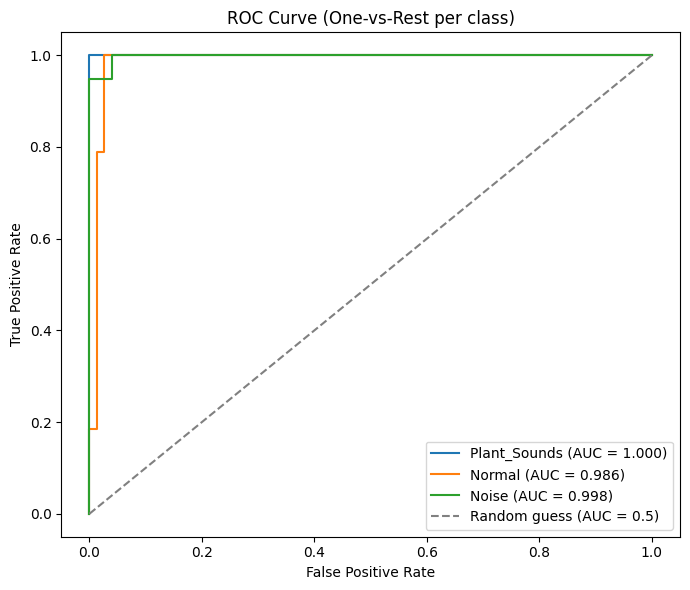

AUC ต่อคลาส: {'Plant_Sounds': np.float64(1.0), 'Normal': np.float64(0.9863), 'Noise': np.float64(0.9979)}
Macro-average AUC: 0.9947


In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

def get_all_probs(model, loader, device):
    """ดึงความน่าจะเป็นของทุกคลาส (softmax) ทั้ง loader ที่ระบุ"""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for input_values, labels in loader:
            input_values = input_values.to(device)
            outputs = model(input_values=input_values)
            probs = torch.softmax(outputs.logits, dim=-1)
            all_probs.append(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.vstack(all_probs), np.array(all_labels)

val_probs_all, val_labels_arr = get_all_probs(model, test_loader, device)  # ใช้ test set สำหรับสรุปผลจริง

n_classes = len(CLASS_FOLDERS)
val_labels_bin = label_binarize(val_labels_arr, classes=list(range(n_classes)))

plt.figure(figsize=(7, 6))
auc_per_class = {}
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(val_labels_bin[:, i], val_probs_all[:, i])
    auc_i = roc_auc_score(val_labels_bin[:, i], val_probs_all[:, i])
    auc_per_class[LABEL2NAME[i]] = auc_i
    plt.plot(fpr, tpr, label=f"{LABEL2NAME[i]} (AUC = {auc_i:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest per class)")
plt.legend()
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(val_labels_bin, val_probs_all, average="macro")
print("AUC ต่อคลาส:", {k: round(v, 4) for k, v in auc_per_class.items()})
print(f"Macro-average AUC: {macro_auc:.4f}")


### เปรียบเทียบ Embedding ก่อน-หลัง Fine-tune ด้วย t-SNE

ก่อนหน้านี้เราดู embedding ของ HuBERT **ก่อน fine-tune** ด้วย PCA/K-means ไปแล้ว
ตรงนี้จะดึง embedding จากโมเดล **หลัง fine-tune** (ผ่าน backbone `model.hubert` ที่เพิ่งเทรนไป) มาเทียบกันด้วย t-SNE
เพื่อโชว์ว่าการ fine-tune ทำให้ embedding ของ 2 คลาสแยกออกจากกันชัดเจนขึ้นจริงหรือไม่


In [23]:
def extract_embedding_finetuned(filepath):
    """ดึง embedding จาก backbone ของโมเดลที่ fine-tune แล้ว (model.hubert)"""
    waveform, sr = torchaudio.load(filepath)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
    wav_np = waveform.squeeze(0).numpy()

    inputs = feature_extractor(wav_np, sampling_rate=SAMPLE_RATE, return_tensors="pt")
    input_values = inputs["input_values"].to(device)

    model.eval()
    with torch.no_grad():
        hidden = model.hubert(input_values).last_hidden_state  # [1, T, H]
        emb = hidden.mean(dim=1).squeeze(0)  # mean pooling ตามแกนเวลา

    return emb.cpu().numpy()

embeddings_after = []
for _, row in df.iterrows():
    embeddings_after.append(extract_embedding_finetuned(row["filepath"]))
embeddings_after = np.array(embeddings_after)

print("Embedding ก่อน fine-tune shape:", embeddings.shape)
print("Embedding หลัง fine-tune shape:", embeddings_after.shape)


Embedding ก่อน fine-tune shape: (750, 768)
Embedding หลัง fine-tune shape: (750, 768)


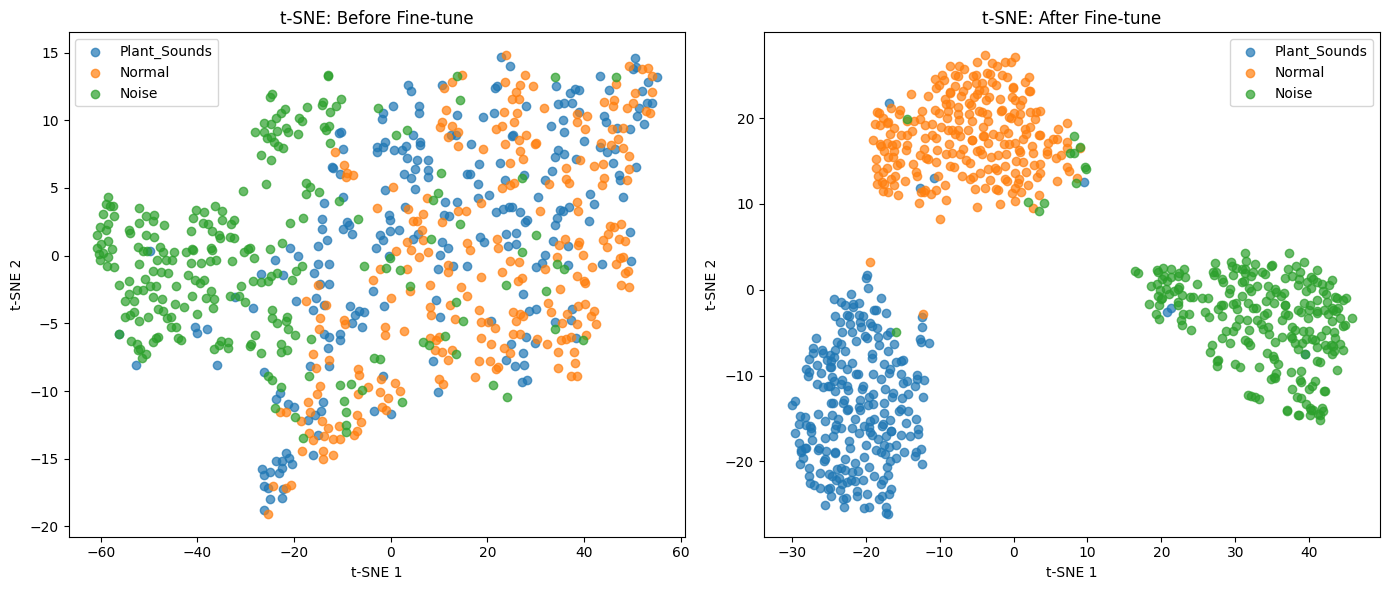

In [24]:
from sklearn.manifold import TSNE

# ปรับ perplexity ให้เหมาะกับขนาดข้อมูล กันพังตอน dataset เล็ก
tsne_perplexity = min(30, max(5, len(df) // 5))

tsne_before = TSNE(n_components=2, random_state=SEED, perplexity=tsne_perplexity, init="pca").fit_transform(embeddings)
tsne_after = TSNE(n_components=2, random_state=SEED, perplexity=tsne_perplexity, init="pca").fit_transform(embeddings_after)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label, name in LABEL2NAME.items():
    mask = labels_arr == label
    axes[0].scatter(tsne_before[mask, 0], tsne_before[mask, 1], label=name, alpha=0.7)
axes[0].set_title("t-SNE: Before Fine-tune")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].legend()

for label, name in LABEL2NAME.items():
    mask = labels_arr == label
    axes[1].scatter(tsne_after[mask, 0], tsne_after[mask, 1], label=name, alpha=0.7)
axes[1].set_title("t-SNE: After Fine-tune")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend()

plt.tight_layout()
plt.show()


In [25]:
# บันทึกโมเดลเป็นไฟล์ .pt พร้อม metadata ที่จำเป็นสำหรับ inference
SAVE_PATH = "hubert_plant_normal_noise_classifier.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "label2id": CLASS_FOLDERS,
    "id2label": LABEL2NAME,
    "model_name": MODEL_NAME,
    "sample_rate": SAMPLE_RATE,
    "max_duration": MAX_DURATION,  # สำคัญมาก! ต้องเก็บไว้เพื่อให้ inference ตัด/pad ความยาวเสียงให้ตรงกับตอนเทรน
}, SAVE_PATH)

print(f"บันทึกโมเดลเรียบร้อยที่: {SAVE_PATH}")


บันทึกโมเดลเรียบร้อยที่: hubert_plant_normal_noise_classifier.pt


### (Optional) บีบอัดโมเดลเป็น INT8 เพื่อลดขนาดไฟล์ .pt

ใช้ **Dynamic Quantization** แปลง weight ของทุก `nn.Linear` layer (attention, feed-forward, classifier head — ส่วนใหญ่ของ parameter ในโมเดลอยู่ตรงนี้) จาก float32 เป็น int8
ลดขนาดไฟล์ได้ประมาณ 3-4 เท่า โดยความแม่นยำมักลดลงไม่มาก (<1% โดยทั่วไป)

⚠️ **ข้อจำกัด**: โมเดลที่ quantize แล้วรันได้เฉพาะ **CPU** เท่านั้น (PyTorch เวอร์ชันปัจจุบันยังไม่รองรับ dynamic quantization บน GPU)
เหมาะสำหรับตอน deploy ให้คนอื่นโหลดไฟล์ไปใช้ ไม่เหมาะกับตอนเทรน


In [31]:
import copy

# ต้องย้ายโมเดลไป CPU ก่อน เพราะ dynamic quantization ใน PyTorch รองรับเฉพาะ CPU
model_cpu = copy.deepcopy(model).to("cpu")
model_cpu.eval()

quantized_model = torch.quantization.quantize_dynamic(
    model_cpu,
    {torch.nn.Linear},   # quantize เฉพาะ Linear layer (ส่วนใหญ่ของ parameter อยู่ตรงนี้)
    dtype=torch.qint8,
)

QUANTIZED_SAVE_PATH = "hubert_plant_normal_noise_classifier_int8.pt"

# ⚠️ ต้องบันทึกด้วย state_dict() เท่านั้น ห้าม torch.save(quantized_model) ทั้งก้อน
# เพราะ HuBERT ใช้ weight normalization (torch.nn.utils.parametrize) ใน positional conv layer
# ซึ่ง PyTorch ไม่อนุญาตให้ pickle ทั้ง module ได้ตรง ๆ (จะ error RuntimeError: Serialization of
# parametrized modules is only supported through state_dict())
torch.save({
    "model_state_dict": quantized_model.state_dict(),
    "label2id": CLASS_FOLDERS,
    "id2label": LABEL2NAME,
    "model_name": MODEL_NAME,
    "sample_rate": SAMPLE_RATE,
    "max_duration": MAX_DURATION,  # สำคัญมาก! ต้องเก็บไว้เพื่อให้ inference ตัด/pad ความยาวเสียงให้ตรงกับตอนเทรน
}, QUANTIZED_SAVE_PATH)

print(f"บันทึกโมเดล INT8 เรียบร้อยที่: {QUANTIZED_SAVE_PATH}")


บันทึกโมเดล INT8 เรียบร้อยที่: hubert_plant_normal_noise_classifier_int8.pt


In [32]:
# เทียบขนาดไฟล์ก่อน-หลัง quantize

def get_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

original_size = get_size_mb(SAVE_PATH)
quantized_size = get_size_mb(QUANTIZED_SAVE_PATH)

print(f"ขนาดไฟล์เดิม (fp32): {original_size:.2f} MB")
print(f"ขนาดไฟล์ INT8:       {quantized_size:.2f} MB")
print(f"ลดลง: {(1 - quantized_size / original_size) * 100:.1f}%")


ขนาดไฟล์เดิม (fp32): 360.84 MB
ขนาดไฟล์ INT8:       116.21 MB
ลดลง: 67.8%


In [33]:
# เช็คความแม่นยำของโมเดล INT8 เทียบกับโมเดลเดิม บน test set (รันบน CPU)

def evaluate_cpu_model(cpu_model, dataframe, feature_extractor, sample_rate, class_folders):
    cpu_model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for _, row in dataframe.iterrows():
            waveform, sr = torchaudio.load(row["filepath"])
            if waveform.shape[0] > 1:
                waveform = waveform.mean(dim=0, keepdim=True)
            if sr != sample_rate:
                waveform = torchaudio.functional.resample(waveform, sr, sample_rate)
            wav_np = waveform.squeeze(0).numpy()

            inputs = feature_extractor(wav_np, sampling_rate=sample_rate, return_tensors="pt")
            logits = cpu_model(input_values=inputs["input_values"]).logits
            pred = torch.argmax(logits, dim=-1).item()

            preds.append(pred)
            labels.append(row["label"])

    return accuracy_score(labels, preds)

int8_acc = evaluate_cpu_model(quantized_model, test_df, feature_extractor, SAMPLE_RATE, CLASS_FOLDERS)
print(f"Test Accuracy (INT8 บน CPU): {int8_acc:.4f}")
print(f"Test Accuracy (fp32 เดิม):    {final_acc:.4f}")


Test Accuracy (INT8 บน CPU): 0.9646
Test Accuracy (fp32 เดิม):    0.9735


## ส่วนที่ 2: Gradio UI สำหรับอัพโหลดไฟล์เสียงมาวิเคราะห์

ขั้นตอนต่อไปนี้จะ:
1. โหลดโมเดลจากไฟล์ `.pt` ที่บันทึกไว้ (จำลองสถานการณ์ใช้งานจริง)
2. สร้างฟังก์ชันสำหรับทำนายคลาส + โชว์ waveform และ spectrogram
3. เปิด Gradio UI ให้อัพโหลดไฟล์ `.wav` มาทดสอบ


In [ ]:
!pip install -q gradio


In [9]:
import gradio as gr

CKPT_PATH = "hubert_plant_normal_noise_classifier.pt"
checkpoint = torch.load(CKPT_PATH, map_location=device)

inference_model = HubertForSequenceClassification.from_pretrained(
    checkpoint["model_name"],
    num_labels=len(checkpoint["label2id"]),
    label2id=checkpoint["label2id"],
    id2label=checkpoint["id2label"],
)
inference_model.load_state_dict(checkpoint["model_state_dict"])
inference_model.to(device)
inference_model.eval()

inference_fe = Wav2Vec2FeatureExtractor.from_pretrained(checkpoint["model_name"])
INFER_SR = checkpoint["sample_rate"]
INFER_MAX_DURATION = checkpoint.get("max_duration", 1.0)  # .get กันเผื่อ checkpoint เก่าที่ยังไม่มีค่านี้
ID2LABEL = checkpoint["id2label"]

print("โหลดโมเดลสำหรับ inference เรียบร้อย")


Some weights of HubertForSequenceClassification were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


โหลดโมเดลสำหรับ inference เรียบร้อย


In [10]:
def analyze_audio(audio_filepath):
    waveform, sr = torchaudio.load(audio_filepath)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != INFER_SR:
        waveform = torchaudio.functional.resample(waveform, sr, INFER_SR)
        sr = INFER_SR
    wav_np = waveform.squeeze(0).numpy()

    # ---- ตัด/pad ให้ยาวเท่ากับตอนเทรนเป๊ะ (สำคัญมาก! ไม่งั้นโมเดลจะเจอ input length ที่ไม่เคยเห็นตอนเทรน) ----
    max_len = int(INFER_SR * INFER_MAX_DURATION)
    if len(wav_np) > max_len:
        wav_np = wav_np[:max_len]
    elif len(wav_np) < max_len:
        wav_np = np.pad(wav_np, (0, max_len - len(wav_np)))

    # ---- ทำนาย ----
    inputs = inference_fe(wav_np, sampling_rate=sr, return_tensors="pt")
    input_values = inputs["input_values"].to(device)
    with torch.no_grad():
        logits = inference_model(input_values=input_values).logits
        probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()

    pred_id = int(np.argmax(probs))
    pred_label = ID2LABEL[pred_id]
    prob_dict = {ID2LABEL[i]: float(probs[i]) for i in range(len(probs))}

    # ---- waveform + spectrogram ----
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

    ax1.plot(np.linspace(0, len(wav_np) / sr, len(wav_np)), wav_np)
    ax1.set_title("Waveform")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")

    S = librosa.feature.melspectrogram(y=wav_np, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=ax2)
    ax2.set_title("Mel Spectrogram")
    fig.colorbar(img, ax=ax2, format="%+2.0f dB")

    plt.tight_layout()

    result_text = f"ทำนาย: {pred_label}  (ความมั่นใจ {probs[pred_id] * 100:.2f}%)"
    return prob_dict, fig, result_text


In [ ]:
demo = gr.Interface(
    fn=analyze_audio,
    inputs=gr.Audio(type="filepath", label="อัพโหลดไฟล์เสียง (.wav)"),
    outputs=[
        gr.Label(num_top_classes=len(ID2LABEL), label="ความน่าจะเป็นแต่ละคลาส"),
        gr.Plot(label="Waveform + Spectrogram"),
        gr.Textbox(label="ผลการทำนาย"),
    ],
    title="HuBERT-Plant_Audio_Classifier",
    description=f"อัพโหลดไฟล์เสียง .wav ความยาว ~1 วินาที ระบบจะจำแนกออกเป็น {len(ID2LABEL)} คลาส: {list(ID2LABEL.values())}",
)

demo.launch(share=True)


* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


## ส่วนที่ 3: Gradio UI แบบใช้โมเดล INT8 (รันบน CPU)

เวอร์ชันนี้โหลดโมเดล `*_int8.pt` ที่ quantize ไว้ก่อนหน้ามาใช้แทน — ไฟล์เล็กกว่า โหลดเร็วกว่า
แต่**รันได้เฉพาะ CPU เท่านั้น** (ไม่ใช้ GPU แม้เครื่องจะมี GPU ก็ตาม เพราะข้อจำกัดของ dynamic quantization ใน PyTorch)


In [12]:
INT8_CKPT_PATH = "hubert_plant_normal_noise_classifier_int8.pt"

int8_checkpoint = torch.load(INT8_CKPT_PATH, map_location="cpu")

# ต้องสร้างโครงสร้างโมเดล fp32 ก่อน แล้ว quantize ให้เป็นโครงสร้างเดียวกับตอน save
# จากนั้นค่อย load_state_dict เข้าไป (จะ state_dict ตรงเป๊ะกับตอน quantize_dynamic ครั้งแรก)
base_model_for_int8 = HubertForSequenceClassification.from_pretrained(
    int8_checkpoint["model_name"],
    num_labels=len(int8_checkpoint["label2id"]),
    label2id=int8_checkpoint["label2id"],
    id2label=int8_checkpoint["id2label"],
)
base_model_for_int8.eval()

int8_inference_model = torch.quantization.quantize_dynamic(
    base_model_for_int8,
    {torch.nn.Linear},
    dtype=torch.qint8,
)
int8_inference_model.load_state_dict(int8_checkpoint["model_state_dict"])
int8_inference_model.to("cpu")
int8_inference_model.eval()

int8_inference_fe = Wav2Vec2FeatureExtractor.from_pretrained(int8_checkpoint["model_name"])
INT8_INFER_SR = int8_checkpoint["sample_rate"]
INT8_INFER_MAX_DURATION = int8_checkpoint.get("max_duration", 1.0)  # .get กันเผื่อ checkpoint เก่าที่ยังไม่มีค่านี้
INT8_ID2LABEL = int8_checkpoint["id2label"]

print("โหลดโมเดล INT8 สำหรับ inference เรียบร้อย (รันบน CPU)")


Some weights of HubertForSequenceClassification were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


โหลดโมเดล INT8 สำหรับ inference เรียบร้อย (รันบน CPU)


In [13]:
def analyze_audio_int8(audio_filepath):
    waveform, sr = torchaudio.load(audio_filepath)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != INT8_INFER_SR:
        waveform = torchaudio.functional.resample(waveform, sr, INT8_INFER_SR)
        sr = INT8_INFER_SR
    wav_np = waveform.squeeze(0).numpy()

    # ---- ตัด/pad ให้ยาวเท่ากับตอนเทรนเป๊ะ (สำคัญมาก! ไม่งั้นโมเดลจะเจอ input length ที่ไม่เคยเห็นตอนเทรน) ----
    max_len = int(INT8_INFER_SR * INT8_INFER_MAX_DURATION)
    if len(wav_np) > max_len:
        wav_np = wav_np[:max_len]
    elif len(wav_np) < max_len:
        wav_np = np.pad(wav_np, (0, max_len - len(wav_np)))

    # ---- ทำนาย (บังคับ CPU เสมอ เพราะโมเดล INT8 รันบน GPU ไม่ได้) ----
    inputs = int8_inference_fe(wav_np, sampling_rate=sr, return_tensors="pt")
    input_values = inputs["input_values"]
    with torch.no_grad():
        logits = int8_inference_model(input_values=input_values).logits
        probs = torch.softmax(logits, dim=-1).squeeze(0).numpy()

    pred_id = int(np.argmax(probs))
    pred_label = INT8_ID2LABEL[pred_id]
    prob_dict = {INT8_ID2LABEL[i]: float(probs[i]) for i in range(len(probs))}

    # ---- waveform + spectrogram ----
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

    ax1.plot(np.linspace(0, len(wav_np) / sr, len(wav_np)), wav_np)
    ax1.set_title("Waveform")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")

    S = librosa.feature.melspectrogram(y=wav_np, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=ax2)
    ax2.set_title("Mel Spectrogram")
    fig.colorbar(img, ax=ax2, format="%+2.0f dB")

    plt.tight_layout()

    result_text = f"ทำนาย (INT8): {pred_label}  (ความมั่นใจ {probs[pred_id] * 100:.2f}%)"
    return prob_dict, fig, result_text


In [ ]:
demo_int8 = gr.Interface(
    fn=analyze_audio_int8,
    inputs=gr.Audio(type="filepath", label="อัพโหลดไฟล์เสียง (.wav)"),
    outputs=[
        gr.Label(num_top_classes=len(INT8_ID2LABEL), label="ความน่าจะเป็นแต่ละคลาส"),
        gr.Plot(label="Waveform + Spectrogram"),
        gr.Textbox(label="ผลการทำนาย"),
    ],
    title="HuBERT-Plant_Audio_Classifier (INT8, CPU): Plant_Sounds vs Normal vs Noise",
    description=f"เวอร์ชัน INT8 ไฟล์เล็กกว่า (~1 วินาที) รันบน CPU อย่างเดียว จำแนกออกเป็น {len(INT8_ID2LABEL)} คลาส: {list(INT8_ID2LABEL.values())}",
)

demo_int8.launch(share=True)


* Running on local URL:  http://127.0.0.1:7861

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
